# LoRA from scratch: a walkthrough

This notebook walks through the two things this repository is about:

1. **The mechanism** -- what `LoRALinear` in `src/lora/lora.py` actually
   computes, checked live rather than taken on faith: zero-init identity,
   exact merging, the adapter on/off switch.
2. **The experiment** -- pretrain a tiny character-level GPT on Shakespeare,
   then adapt it to Don Quijote five different ways, and compare what each
   one costs and forgets.

The heavy training (pretraining plus five adaptation runs, roughly
20-30 minutes of CPU time in total) was run separately with
`python scripts/run_experiment.py`, which writes `results/results.json`.
This notebook loads that file rather than retraining anything, so it stays
fast to open and re-execute; every number and sample of text below came
from that real run, not from this notebook.

## 1. The equation, checked live

LoRA replaces a frozen weight matrix `W0` with `W0 x + (alpha/r) B A x`, where `B` starts at zero. The three cells below check the three claims that make this work, on a small standalone `nn.Linear` -- no GPT involved yet.

In [1]:
import sys
sys.path.insert(0, "src")

import torch
import torch.nn as nn

from lora.lora import LoRALinear

torch.manual_seed(0)
base = nn.Linear(16, 8)
x = torch.randn(4, 16)

layer = LoRALinear(base, r=4, alpha=4)
print("B is exactly zero at init:", torch.equal(layer.lora_B, torch.zeros_like(layer.lora_B)))
print("forward matches the frozen base layer:", torch.allclose(layer(x), base(x)))


B is exactly zero at init: True
forward matches the frozen base layer: True


In [2]:
# Give A and B nonzero values, as if some training had happened, then check
# that merging into W0 produces exactly the same forward pass.
torch.manual_seed(1)
with torch.no_grad():
    layer.lora_A.copy_(torch.randn_like(layer.lora_A))
    layer.lora_B.copy_(torch.randn_like(layer.lora_B))

unmerged_out = layer(x)
layer.merge()
merged_out = layer(x)

print("merged == unmerged forward:", torch.allclose(unmerged_out, merged_out, atol=1e-6))
print("max abs difference:", (unmerged_out - merged_out).abs().max().item())
layer.unmerge()


merged == unmerged forward: True
max abs difference: 1.9073486328125e-06


In [3]:
# The `enabled` switch never touches base.weight at all, so turning the
# adapter off after training reproduces the *original* frozen layer exactly,
# no matter how far A and B moved.
expected = torch.nn.functional.linear(x, layer.base.weight, layer.base.bias)
layer.enabled = False
print("adapter-off forward == original frozen layer:", torch.allclose(layer(x), expected))
layer.enabled = True


adapter-off forward == original frozen layer: True


## 2. The real experiment

Now the actual run: a 2-layer, 2-head, 128-dim character GPT, pretrained on Shakespeare and adapted to Don Quijote with full fine-tuning, LoRA at three ranks, and a head-only baseline. Loading the results from the run that produced `results/results.json`.

In [4]:
import json
from pathlib import Path

results = json.loads(Path("results/results.json").read_text())
cfg = results["config"]
print(f"model: {cfg['n_layer']} layers, {cfg['n_head']} heads, d_model={cfg['n_embd']}, "
      f"block_size={cfg['block_size']}, {cfg['total_params']:,} parameters")
print(f"vocab size (union of both corpora): {cfg['vocab_size']}")
print(f"pretrain steps: {cfg['pretrain_steps']}, adaptation steps per method: {cfg['adapt_steps']}")
print(f"total wall time: {results['total_wall_seconds']/60:.1f} minutes")


model: 2 layers, 2 heads, d_model=128, block_size=128, 438,016 parameters
vocab size (union of both corpora): 97
pretrain steps: 2500, adaptation steps per method: 800
total wall time: 20.9 minutes


In [5]:
pretrain = results["pretrain"]
print(f"pretrain final val loss on Shakespeare: {pretrain['val_loss_a']:.4f}")
print("sample (prompt 'ROMEO:'):\n")
print(pretrain["sample"])


pretrain final val loss on Shakespeare: 1.9074
sample (prompt 'ROMEO:'):

ROMEO:
I net as theemy the hen be offors
As then he award, what of look hear hear'd well thou
Lir, be see the at all the siers? a cautious,
Or sire mestere morrent to ale made as the be in up spenselvower;
And is brother have sto one as my lars the mon,
And fore this fold up morrowd 'Dains thought,
But th


### Results table

Trainable parameters, final validation loss on Quijote (corpus B), validation loss back on Shakespeare after adapting (corpus A -- catastrophic forgetting), and, for the LoRA runs, validation loss on Shakespeare with the adapters switched off.

In [6]:
rows = [("pretrained (no adapt)", 0, 0.0, None, pretrain["val_loss_a"], None)]
for m in results["methods"]:
    rows.append((
        m["method"], m["trainable_params"], m["trainable_pct"],
        m["val_loss_b_final"], m["val_loss_a_after_adapt"], m["val_loss_a_adapter_off"],
    ))

header = f"{'method':<24}{'trainable':>12}{'% params':>10}{'val loss B':>12}{'val loss A':>12}{'A, adapter off':>16}"
print(header)
print("-" * len(header))
for method, trainable, pct, vb, va, va_off in rows:
    vb_s = f"{vb:.4f}" if vb is not None else "--"
    va_off_s = f"{va_off:.4f}" if va_off is not None else "--"
    print(f"{method:<24}{trainable:>12,}{pct:>9.2f}%{vb_s:>12}{va:>12.4f}{va_off_s:>16}")


method                     trainable  % params  val loss B  val loss A  A, adapter off
--------------------------------------------------------------------------------------
pretrained (no adapt)              0     0.00%          --      1.9074              --
full                         438,016   100.00%      1.7567      3.5686              --
lora1                          1,536     0.35%      2.5490      2.5163          1.9060
lora4                          6,144     1.38%      2.3996      2.7474          1.9142
lora16                        24,576     5.31%      2.2862      2.8979          1.9094
head                          12,416     2.83%      2.2377      2.6867              --


### Loss curves during adaptation

Validation loss on Quijote (corpus B) over the course of adaptation, one line per method.

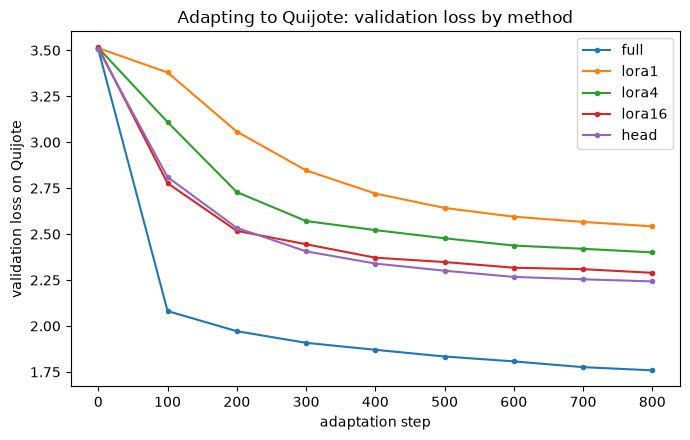

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
for m in results["methods"]:
    steps = [h["step"] for h in m["history"]]
    val = [h["val_loss"] for h in m["history"]]
    ax.plot(steps, val, marker="o", markersize=3, label=m["method"])
ax.set_xlabel("adaptation step")
ax.set_ylabel("validation loss on Quijote")
ax.set_title("Adapting to Quijote: validation loss by method")
ax.legend()
fig.tight_layout()
plt.show()


### Forgetting: Shakespeare loss before vs. after adapting to Quijote

Bars below the pretrain baseline line mean the model *improved* on Shakespeare (unlikely, and not what happens here); bars above it mean it forgot some of what pretraining taught it.

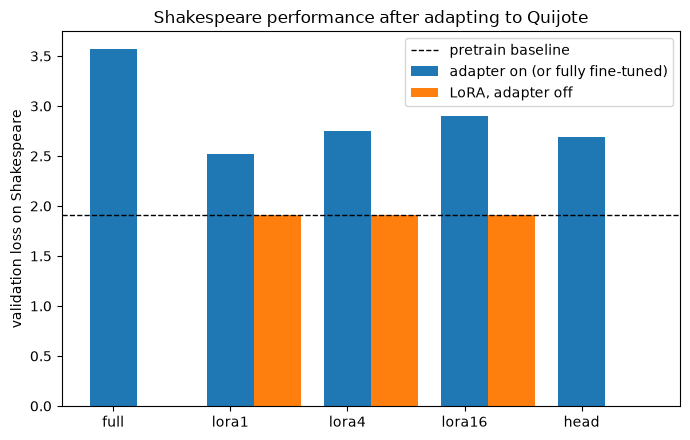

In [8]:
methods = [m["method"] for m in results["methods"]]
after = [m["val_loss_a_after_adapt"] for m in results["methods"]]
off = [m["val_loss_a_adapter_off"] for m in results["methods"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
x = range(len(methods))
ax.bar(x, after, width=0.4, label="adapter on (or fully fine-tuned)", align="edge")
ax.bar([i + 0.4 for i in x], [o if o is not None else 0 for o in off], width=0.4,
       label="LoRA, adapter off", align="edge")
ax.axhline(pretrain["val_loss_a"], color="black", linestyle="--", linewidth=1, label="pretrain baseline")
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(methods)
ax.set_ylabel("validation loss on Shakespeare")
ax.set_title("Shakespeare performance after adapting to Quijote")
ax.legend()
fig.tight_layout()
plt.show()


### Generation samples

Qualitative check: each adapted model, prompted with the opening words of Don Quijote, sampled at temperature 0.8.

In [9]:
for m in results["methods"]:
    print(f"--- {m['method']} ---")
    print(m["sample"])
    print()


--- full ---
En un lugar de la Mancharreza.


— A puestro
— Sancho de los pentos que escualención suera que sin pros porque volveciones las impo en ojar decega on acarladrá haya vecho, peroña de los he ser paderon volitaba de se nuego diste atra, con don Quijote de Pros que pues, a consa del muchosto prestaba darleco apondo por como, p

--- lora1 ---
En un lugar de la Manchas wure no, so, que; calemannta m y, mededone redos andes poln Porer,
la ge de! son do sao Jlledateter n ru so lo me, a to terisuas ne ma qua
po toodesen: o didelcaiesicometon tho del comansu dairtede, is;o, vematedas  donse somesto on quo purto ou eseader toldo era, me :

Ealade que To-s to rit thal

--- lora4 ---
En un lugar de la Manchanca,
Piras ledel. Ro coron udabéote von so Grino pendescias, no-re da no ever pera que terasura focha
To mu, der le te quen cato se tho, ro se po su hiïgada que e en sal ngado cas ple co, des que wero mo el, pes corceso destragande en laua y, werpe morito burüus illamas pe---
na tey

## Conclusions

See the README's Results section for the full write-up. The short version the numbers above support: LoRA reaches Quijote validation loss close to full fine-tuning while training a small fraction of the parameters, and unlike full fine-tuning or head-only training, its effect on the frozen base model is genuinely reversible -- switching the adapters off recovers the pretrained Shakespeare loss, because the base weights were never written to in the first place.